In [1]:
import pandas as pd
import numpy as np
import re 
from IPython.display import display, HTML

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV 
from sklearn.metrics import classification_report, confusion_matrix, f1_score, hamming_loss, jaccard_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from imblearn.ensemble import BalancedRandomForestClassifier
from xgboost import XGBClassifier
from sklearn.multioutput import MultiOutputClassifier, ClassifierChain
from scipy.stats import entropy

import shap

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.max_columns', None)

data= pd.read_csv("anti_total.csv", index_col=False)

In [3]:
start_index = data.columns.get_loc('Acyclovir')
end_index = data.columns.get_loc('tenofovir/emtricitabine/rilpivirine')

In [4]:
abx_cols = data.columns[start_index:end_index+1]
col_sum = data[abx_cols].sum()

In [5]:
abx_cols = data.columns[start_index:end_index+1]
col_sum = data[abx_cols].sum()

In [6]:
final_cols = col_sum[col_sum >= 400].index.tolist()
base_cols = [c for c in data.columns if c not in abx_cols]
data_filter = data[base_cols + final_cols]

In [7]:
data_filter[final_cols].sum().sort_values(ascending=False)

Amoxicillin/Clavulanic acid    5515.0
Flomoxef                       5196.0
Cefazolin                      2371.0
Cefixime                       2166.0
Ciprofloxacin                  2071.0
Azithromycin                   2053.0
Cefuroxime                     1691.0
Piperacillin/Tazobactam        1511.0
Cefoperazone/sulbactam         1412.0
Peramivir                      1119.0
Baloxavir marboxil             1085.0
Metronidazole                  1020.0
Cefadroxil                      918.0
Oseltamivir                     835.0
Levofloxacin                    720.0
Clindamycin                     624.0
Gentamicin                      623.0
Ceftriaxone                     610.0
Cephalexin                      517.0
Ampicillin                      423.0
dtype: float64

In [8]:
all_site_cols = [
    'INFECTIONSITE1', 'INFECTIONSITE2', 'INFECTIONSITE3',
    'INFECTIONSITE4', 'INFECTIONSITE5', 'INFECTIONSITE9', 
    'OTHERINFECTIONSITE_flag'
]

temp_df = data_filter[all_site_cols].copy().astype(str).apply(lambda x: x.str.strip())
temp_df = temp_df.replace(['', 'nan', 'None', 'nan.0'], '0')

temp_df = temp_df.astype(float)

has_site_mask = (temp_df > 0).any(axis=1)

site_samples = data[has_site_mask].copy()

print(f"原始樣本數: {len(data)}")
print(f"至少標註一個部位的樣本數: {len(site_samples)}")
print(f"被排除掉的『全空/全0』樣本數: {len(data) - len(site_samples)}")


原始樣本數: 27968
至少標註一個部位的樣本數: 11880
被排除掉的『全空/全0』樣本數: 16088


In [9]:
len(site_samples), len(site_samples['ACCOUNTNO'])

(11880, 11880)

In [10]:
site_samples['Clindamycin'].sum(), site_samples['Gentamicin'].sum()

(379.0, 201.0)

In [11]:
roomno_mapping = {'A': '1', 'C': '2', 'D': '3', 'E': '4', 'H': '5', 'K': '6'}
site_samples['ROOMNO'] = site_samples['ROOMNO'].map(roomno_mapping)          

site_samples['SEX'] = site_samples['SEX'].map({'M': 1, 'F': 0})

yn_cols = [
    'ISSEPSIS0', 'FEVER', 'DM', 'CARDIOVASCULAR', 
    'RESPIRATORY', 'CNS', 'CANCER', 'LIVER', 'KIDNEY', 'AUTOIMMUNE'
]

for col in yn_cols:
    site_samples[col] = site_samples[col].map({'Y': 1, 'N': 0})

In [12]:
feature_cols = list(set(site_samples.columns) - set(abx_cols))
X = site_samples[feature_cols]
y = site_samples[final_cols]

In [13]:
X.shape, y.shape

((11880, 68), (11880, 20))

In [14]:
X = X.drop(columns=['ACCOUNTNO','ROOMNO', 'INTIME', 'Influenza Virus A level', 'FIRST_ORDERTIME', 'ISSEPSIS0'])
y = y.drop(columns=['Peramivir', 'Baloxavir marboxil', 'Oseltamivir', 'Cephalexin', 'Cefadroxil'])
                    #'Amoxicillin', 'Doxycycline', 'Acyclovir', 'Valaciclovir', 'Tenofovir alafenamide', 'Ceftazidime'])# 去掉抗病毒的藥(前3) 

In [15]:
X.columns

Index(['CHECKITEM27SCORE', 'AUTOIMMUNE', 'PH', 'CHECKITEM31SCORE',
       'CHECKITEM30SCORE', 'CNS', 'O2 SAT', 'CARDIOVASCULAR', 'Na',
       'CHECKITEM32SCORE', 'INFECTIONSITE2', 'CHECKITEM28SCORE',
       'INFECTIONSITE5', 'Nitrite level', 'VITALSIGNSDBP', 'CHECKITEM29SCORE',
       'PCO2', 'Leukocyte level', 'RESPIRATORY', 'INR', 'FEVER',
       'Microscopic WBC level', 'PT', 'Neutrophil Seg.', 'WBC', 'VITALSIGNSRR',
       'AGE', 'INFECTIONSITE4', 'CRP', 'HCO3', 'MAP', 'SEX', 'CHECKITEM28A',
       'StayTime_hours', 'KIDNEY', 'VITALSIGNSGCS', 'HST', 'INFECTIONSITE3',
       'K', 'VITALSIGNSSPO2', 'PLT', 'Creatinine', 'CANCER', 'Bacteria level',
       'CHECKITEM27', 'INFECTIONSITE1', 'INJURELEVEL', 'LIVER', 'Lymphocyte',
       'VITALSIGNSPR', 'Absolute Neutrophil count', 'APTT', 'Hb', 'GPT',
       'Microscopic RBC level', 'T.Bilirubin', 'OTHERINFECTIONSITE_flag', 'DM',
       'INFECTIONSITE9', 'VITALSIGNSBT', 'BE(ecf)', 'Ht'],
      dtype='object')

In [16]:
####################### Missing 70~80% #######################

# 檢驗

X['Leukocyte level_flag'] = (
     X['Leukocyte level'].fillna('').str.strip().ne('').astype(int))

X['Nitrite level_flag'] = (
     X['Nitrite level'].fillna('').str.strip().ne('').astype(int))

X['Bacteria level_flag'] = (
     X['Bacteria level'].fillna('').str.strip().ne('').astype(int))

X['Microscopic RBC level_flag'] = (
     X['Microscopic RBC level'].fillna('').str.strip().ne('').astype(int))

X['Microscopic WBC level_flag'] = (
     X['Microscopic WBC level'].fillna('').str.strip().ne('').astype(int))

X['PH_flag'] = (
     X['Microscopic RBC level'].fillna('').str.strip().ne('').astype(int))



# 計分

X['CHECKITEM29SCORE_flag'] = (
     X['CHECKITEM29SCORE'].fillna('').str.strip().ne('').astype(int))

X['CHECKITEM30SCORE_flag'] = (
     X['CHECKITEM30SCORE'].fillna('').str.strip().ne('').astype(int))


####################### Missing > 80% #######################

# 檢驗

X['HST_flag'] = (
     X['HST'].fillna('').str.strip().ne('').astype(int))

X['T.Bilirubin_flag'] = (
     X['T.Bilirubin'].fillna('').str.strip().ne('').astype(int))

X['PT_flag'] = (
     X['PT'].fillna('').str.strip().ne('').astype(int))

X['HST_flag'] = (
     X['HST'].fillna('').str.strip().ne('').astype(int))

X['INR_flag'] = (
     X['INR'].fillna('').str.strip().ne('').astype(int))

X['APTT_flag'] = (
     X['APTT'].fillna('').str.strip().ne('').astype(int))

X['PCO2_flag'] = (
     X['PCO2'].fillna('').str.strip().ne('').astype(int))

X['HCO3_flag'] = (
     X['HCO3'].fillna('').str.strip().ne('').astype(int))


X['BE(ecf)_flag'] = (
     X['BE(ecf)'].fillna('').str.strip().ne('').astype(int))

X['O2 SAT_flag'] = (
     X['O2 SAT'].fillna('').str.strip().ne('').astype(int))

# 計分

X['CHECKITEM28A_flag'] = (
     X['CHECKITEM28A'].fillna('').str.strip().ne('').astype(int))

X['CHECKITEM27_flag'] = (
     X['CHECKITEM27'].fillna('').str.strip().ne('').astype(int))

X['CHECKITEM27SCORE_flag'] = (
     X['CHECKITEM27SCORE'].fillna('').str.strip().ne('').astype(int))

X['CHECKITEM28SCORE_flag'] = (
     X['CHECKITEM28SCORE'].fillna('').str.strip().ne('').astype(int))

X['CHECKITEM31SCORE_flag'] = (
     X['CHECKITEM31SCORE'].fillna('').str.strip().ne('').astype(int))

X['CHECKITEM32SCORE_flag'] = (
     X['CHECKITEM32SCORE'].fillna('').str.strip().ne('').astype(int))


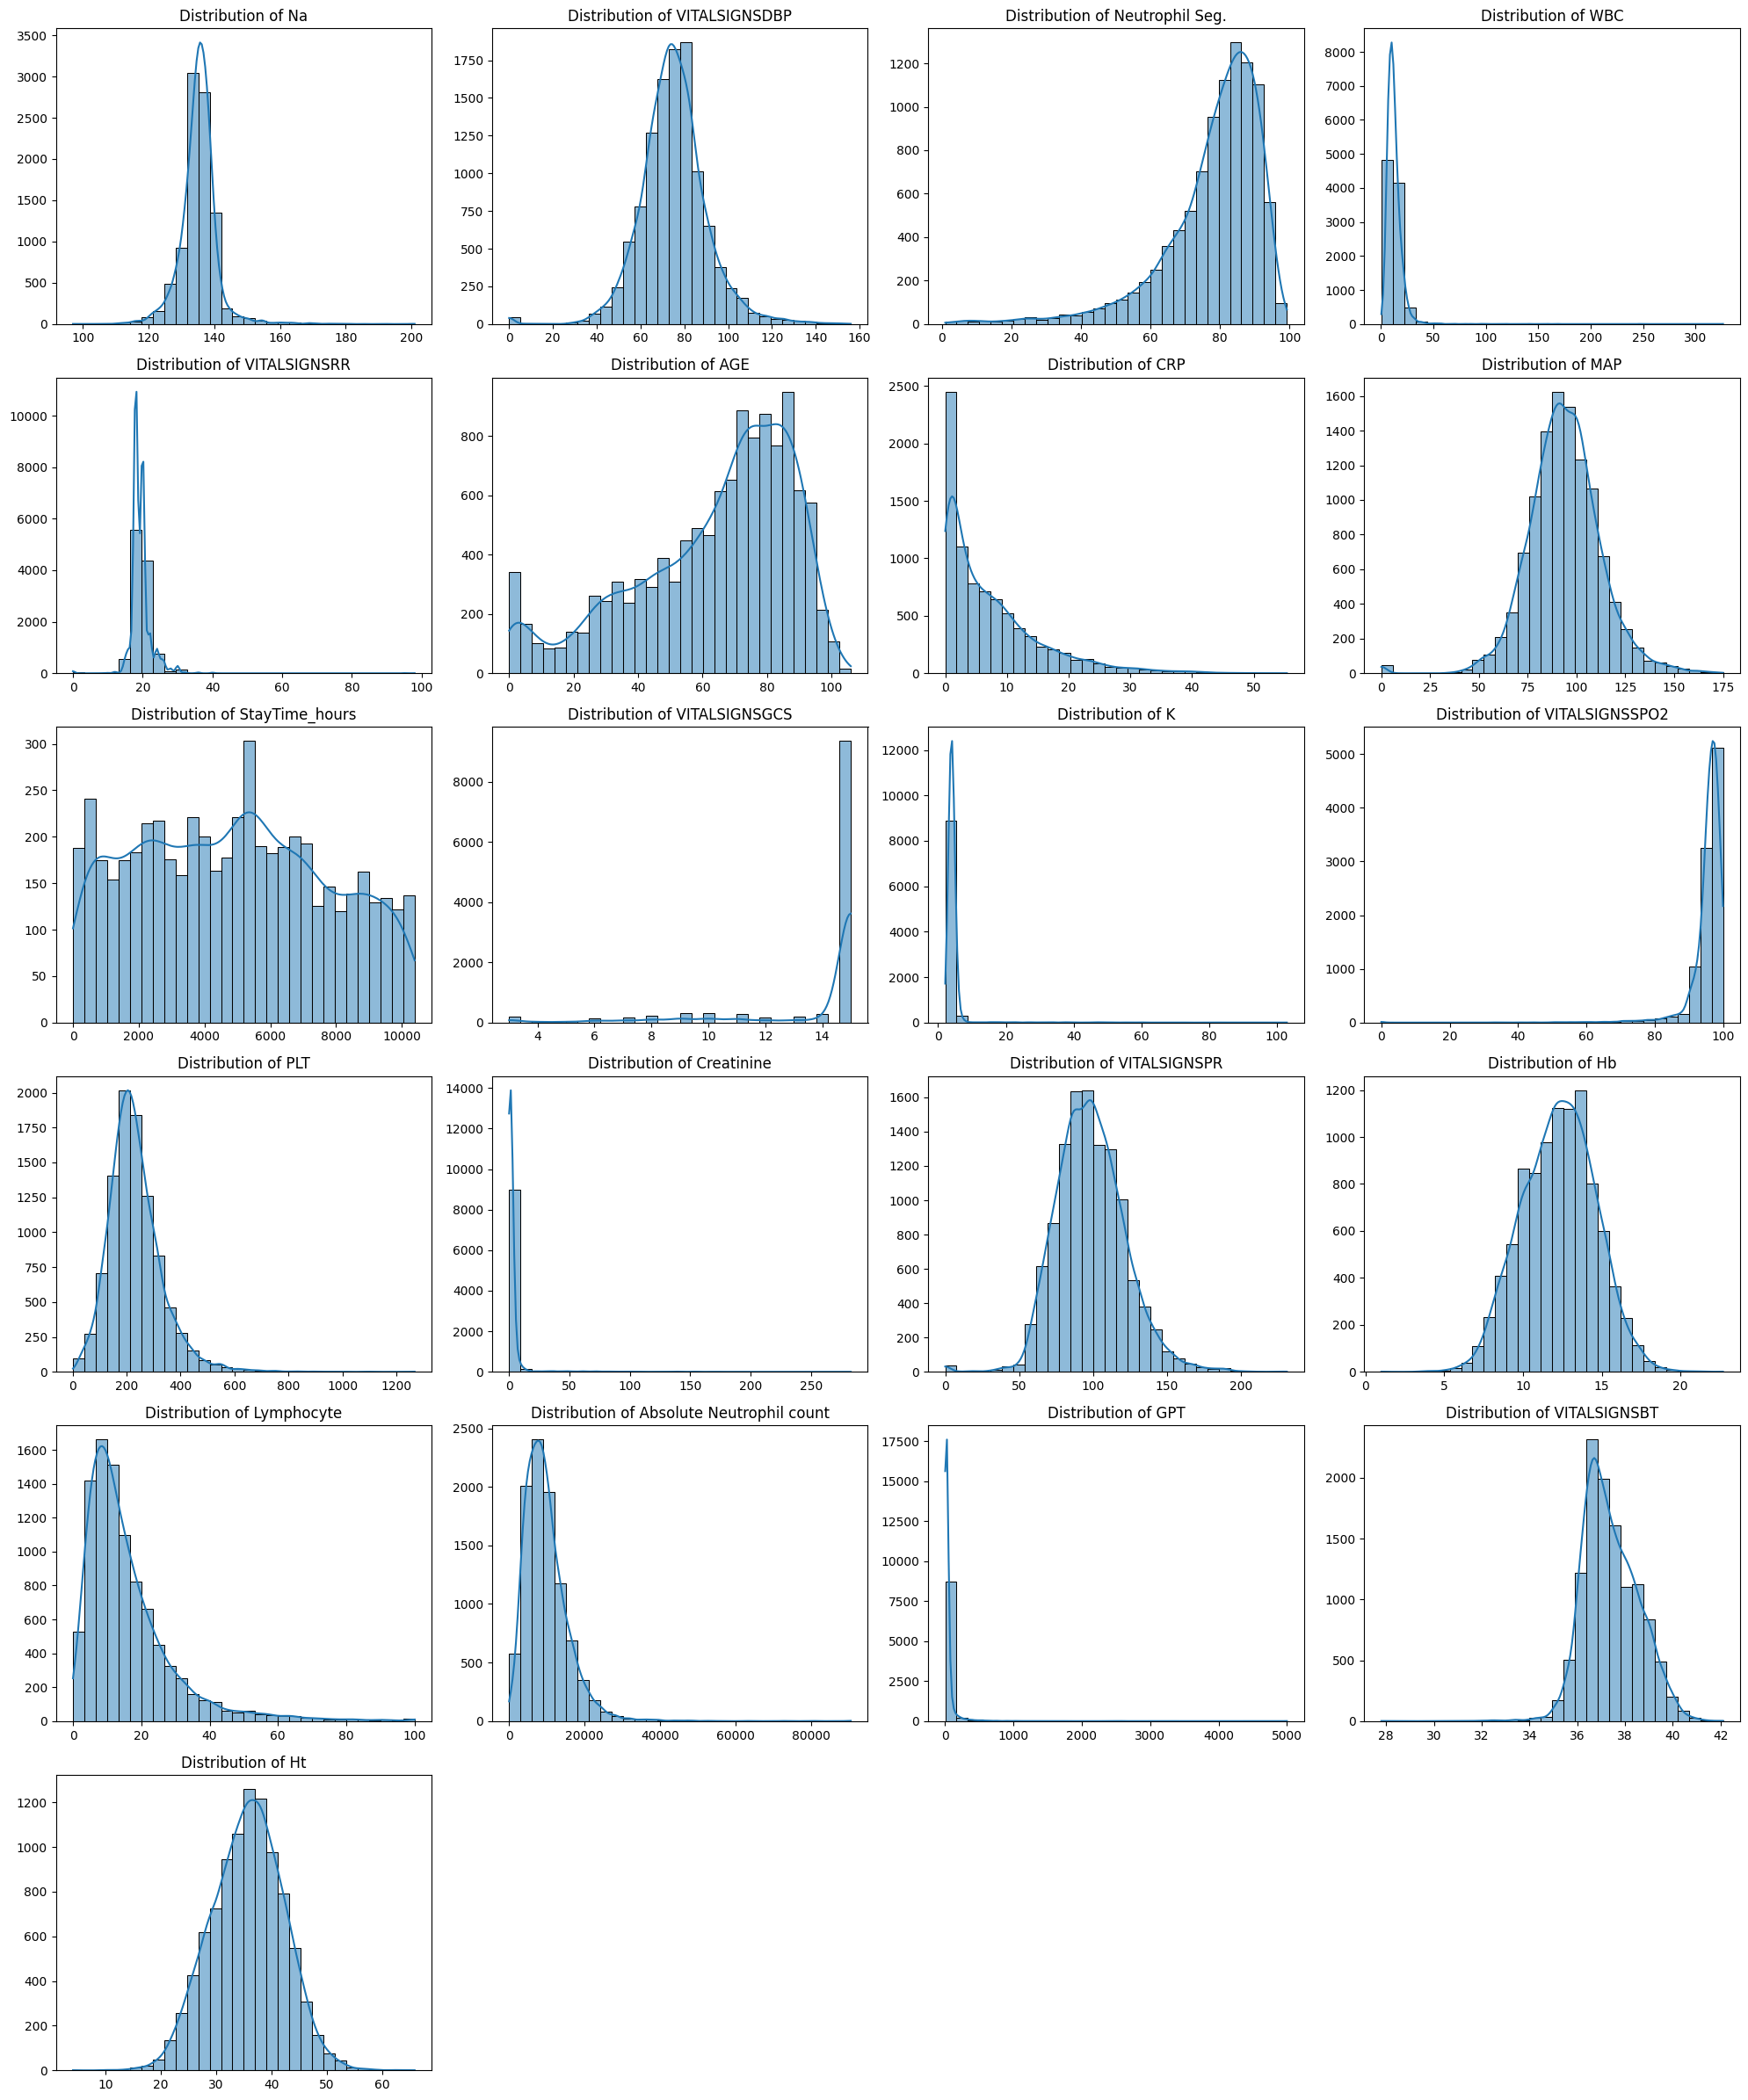

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

df = X

vital_cols = list(set(['AGE', 'StayTime_hours', 'VITALSIGNSBT', 'VITALSIGNSPR', 'VITALSIGNSRR', 'VITALSIGNSSPO2', 'VITALSIGNSDBP', 'VITALSIGNSGCS', 'MAP', 'Hb', 'WBC', 
            'Ht', 'PLT', 'Lymphocyte', 'Neutrophil Seg.', 'Absolute Neutrophil count', 'Na', 'K', 'Creatinine', 'GPT', 'CRP']))

# 設定每列顯示幾個圖
cols_per_row = 4
rows = math.ceil(len(vital_cols) / cols_per_row)

# 建立畫布
fig, axes = plt.subplots(rows, cols_per_row, figsize=(20, rows * 4))
axes = axes.flatten() # 將多維陣列拉平，方便迴圈讀取

for i, col in enumerate(vital_cols):
    if col in df.columns:
        # 繪製直方圖 + 密度曲線(kde)
        sns.histplot(df[col].dropna(), kde=True, ax=axes[i], bins=30)
        axes[i].set_title(f'Distribution of {col}', fontsize=12)
        axes[i].set_xlabel('')
        axes[i].set_ylabel('')
    else:
        axes[i].set_axis_off() # 如果欄位不存在就留白

# 移除多餘的空白子圖
for j in range(i + 1, len(axes)):
    axes[j].set_axis_off()

plt.tight_layout()
plt.show()

In [18]:
lower_bound = X.quantile(0.01)
upper_bound = X.quantile(0.99)

outliers_low = (X < lower_bound).sum()
outliers_high = (X > upper_bound).sum()

outlier_summary = pd.DataFrame({
    'Low_Outliers (<1%)': outliers_low,
    'High_Outliers (>99%)': outliers_high,
    'Total_Outliers': outliers_low + outliers_high
})

print(f"全資料集總離群值筆數: {outlier_summary['Total_Outliers'].sum()}")
print("\n各欄位離群值統計 (前 10 名):")
print(outlier_summary.sort_values('Total_Outliers', ascending=False).head(10))


全資料集總離群值筆數: 4051

各欄位離群值統計 (前 10 名):
                           Low_Outliers (<1%)  High_Outliers (>99%)  \
VITALSIGNSPR                              116                   115   
VITALSIGNSDBP                             102                   111   
MAP                                       101                   106   
Absolute Neutrophil count                  96                    96   
VITALSIGNSBT                               91                   101   
WBC                                        95                    96   
Ht                                         97                    92   
PLT                                        93                    95   
Lymphocyte                                 87                    96   
Hb                                         89                    91   

                           Total_Outliers  
VITALSIGNSPR                          231  
VITALSIGNSDBP                         213  
MAP                                   207  
Absol

In [19]:
# outlier修改為1%或99% quantile
X = X.clip(lower=lower_bound, upper=upper_bound, axis=1)

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.1, random_state = 123)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((10692, 85), (10692, 15), (1188, 85), (1188, 15))

In [21]:
X_train.isnull().sum(), X_test.isnull().sum()

(CHECKITEM27SCORE         7121
 AUTOIMMUNE                  0
 PH                       6055
 CHECKITEM31SCORE         9585
 CHECKITEM30SCORE         6845
                          ... 
 CHECKITEM27_flag            0
 CHECKITEM27SCORE_flag       0
 CHECKITEM28SCORE_flag       0
 CHECKITEM31SCORE_flag       0
 CHECKITEM32SCORE_flag       0
 Length: 85, dtype: int64,
 CHECKITEM27SCORE          817
 AUTOIMMUNE                  0
 PH                        670
 CHECKITEM31SCORE         1077
 CHECKITEM30SCORE          788
                          ... 
 CHECKITEM27_flag            0
 CHECKITEM27SCORE_flag       0
 CHECKITEM28SCORE_flag       0
 CHECKITEM31SCORE_flag       0
 CHECKITEM32SCORE_flag       0
 Length: 85, dtype: int64)

In [22]:
X_train.dtypes, X_test.dtypes

(CHECKITEM27SCORE         float64
 AUTOIMMUNE                 int64
 PH                       float64
 CHECKITEM31SCORE         float64
 CHECKITEM30SCORE         float64
                           ...   
 CHECKITEM27_flag           int32
 CHECKITEM27SCORE_flag      int32
 CHECKITEM28SCORE_flag      int32
 CHECKITEM31SCORE_flag      int32
 CHECKITEM32SCORE_flag      int32
 Length: 85, dtype: object,
 CHECKITEM27SCORE         float64
 AUTOIMMUNE                 int64
 PH                       float64
 CHECKITEM31SCORE         float64
 CHECKITEM30SCORE         float64
                           ...   
 CHECKITEM27_flag           int32
 CHECKITEM27SCORE_flag      int32
 CHECKITEM28SCORE_flag      int32
 CHECKITEM31SCORE_flag      int32
 CHECKITEM32SCORE_flag      int32
 Length: 85, dtype: object)

In [23]:
y_train.sum().sort_values(ascending=False)

Flomoxef                       4683.0
Amoxicillin/Clavulanic acid    1408.0
Piperacillin/Tazobactam        1358.0
Cefoperazone/sulbactam         1259.0
Metronidazole                   830.0
Ciprofloxacin                   784.0
Cefixime                        775.0
Azithromycin                    635.0
Ceftriaxone                     561.0
Cefazolin                       526.0
Levofloxacin                    453.0
Cefuroxime                      451.0
Clindamycin                     331.0
Gentamicin                      180.0
Ampicillin                       82.0
dtype: float64

In [24]:
# 轉數值

num_cols = ['AGE', 'StayTime_hours', 'VITALSIGNSBT', 'VITALSIGNSPR', 'VITALSIGNSRR', 'VITALSIGNSSPO2', 'VITALSIGNSDBP', 'VITALSIGNSGCS', 'MAP', 'Hb', 'WBC', 
            'Ht', 'PLT', 'Lymphocyte', 'Neutrophil Seg.', 'Absolute Neutrophil count', 'Na', 'K', 'Creatinine', 'GPT', 'CRP']

# num_cols = ['Neutrophil Seg.', 'VITALSIGNSBT', 'VITALSIGNSPR', 'VITALSIGNSRR', 'VITALSIGNSSPO2', 'VITALSIGNSDBP', 'VITALSIGNSGCS', 'MAP', 'WBC', 
#             'Lymphocyte', 'CRP', 'Hb', 'Creatinine', 'Leukocyte', 'PCO2', 'INR', 'Absolute Neutrophil count', 'Ht', 'HST', 'BE(ecf)', 'T.Bilirubin',
#            'Na', 'K', 'GPT', 'O2 SAT', 'HCO3', 'PT', 'APTT', 'PLT']

for col in num_cols:
    X_train[col] = pd.to_numeric(X_train[col], errors='coerce')
    X_test[col] = pd.to_numeric(X_test[col], errors='coerce')

In [25]:
# vital sign impute
vital_cols = ['AGE', 'StayTime_hours', 'VITALSIGNSBT', 'VITALSIGNSPR', 'VITALSIGNSRR', 'VITALSIGNSSPO2', 'VITALSIGNSDBP', 'VITALSIGNSGCS', 'MAP', 'Hb', 'WBC', 
              'Ht', 'PLT', 'Lymphocyte', 'Neutrophil Seg.', 'Absolute Neutrophil count', 'Na', 'K', 'Creatinine', 'GPT', 'CRP']


for col in vital_cols:
    # X_train[col + "_missing"] = X_train[col].isna().astype(int) # missing indicator
    median = X_train[col].median()
    X_train[col] = X_train[col].fillna(median)
    
    # X_test[col + "_missing"] = X_test[col].isna().astype(int) # missing indicator
    X_test[col] = X_test[col].fillna(median)

In [26]:
# 取 log

X_train['CRP'] = np.log1p(X_train['CRP'])
X_test['CRP'] = np.log1p(X_test['CRP'])

X_train['PLT'] = np.log1p(X_train['PLT'])
X_test['PLT'] = np.log1p(X_test['PLT'])

X_train['WBC'] = np.log1p(X_train['WBC'])
X_test['WBC'] = np.log1p(X_test['WBC'])

X_train['AGE'] = np.log1p(X_train['AGE'])
X_test['AGE'] = np.log1p(X_test['AGE'])

X_train['K'] = np.log1p(X_train['K'])
X_test['K'] = np.log1p(X_test['K'])

X_train['GPT'] = np.log1p(X_train['GPT'])
X_test['GPT'] = np.log1p(X_test['GPT'])

X_train['VITALSIGNSSPO2'] = np.log1p(X_train['VITALSIGNSSPO2'])
X_test['VITALSIGNSSPO2'] = np.log1p(X_test['VITALSIGNSSPO2'])

X_train['Absolute Neutrophil count'] = np.log1p(X_train['Absolute Neutrophil count'])
X_test['Absolute Neutrophil count'] = np.log1p(X_test['Absolute Neutrophil count'])

X_train['VITALSIGNSBT'] = np.log1p(X_train['VITALSIGNSBT'])
X_test['VITALSIGNSBT'] = np.log1p(X_test['VITALSIGNSBT'])

X_train['VITALSIGNSRR'] = np.log1p(X_train['VITALSIGNSRR'])
X_test['VITALSIGNSRR'] = np.log1p(X_test['VITALSIGNSRR'])

X_train['Creatinine'] = np.log1p(X_train['Creatinine'])
X_test['Creatinine'] = np.log1p(X_test['Creatinine'])

X_train['Na'] = np.log1p(X_train['Na'])
X_test['Na'] = np.log1p(X_test['Na'])

# X_train['Lymphocyte'] = np.log1p(X_train['Lymphocyte'])
# X_test['Lymphocyte'] = np.log1p(X_test['Lymphocyte'])

In [27]:
X_train['Lymphocyte']

26125    12.5
23213    18.2
15823    26.5
18061    10.6
11588    44.8
         ... 
18385    11.1
12239     5.0
3422     57.0
27374    37.0
8585     17.2
Name: Lymphocyte, Length: 10692, dtype: float64

In [28]:
# fill score

score_cols = ['Leukocyte level_flag', 'Nitrite level_flag', 'Bacteria level_flag', 'Microscopic RBC level_flag', 'Microscopic WBC level_flag', 'PH_flag',
              'CHECKITEM29SCORE_flag', 'CHECKITEM30SCORE_flag', # 70~80% missing
              'HST_flag','T.Bilirubin_flag', 'PT_flag', 'HST_flag', 'INR_flag', 'APTT_flag', 'PCO2_flag', 'HCO3_flag', 'BE(ecf)_flag',
              'O2 SAT_flag', 'CHECKITEM28A_flag', 'CHECKITEM27_flag', 'CHECKITEM27SCORE_flag', 'CHECKITEM28SCORE_flag', 
              'CHECKITEM31SCORE_flag', 'CHECKITEM32SCORE_flag'] # > 80% missing

for col in score_cols:
    X_train[col] = pd.to_numeric(X_train[col], errors='coerce')
    X_train[col] = X_train[col].fillna(-1)

    X_test[col] = pd.to_numeric(X_test[col], errors='coerce')
    X_test[col] = X_test[col].fillna(-1)

In [29]:
y_train.sum(axis=1).mean() # 每人平均用1.24個抗生素

1.3389450056116723

In [30]:
drop_cols = ['HST', 'Leukocyte level' , 'Nitrite level', 'Bacteria level', 'Microscopic RBC level', 'Microscopic WBC level' , 
             'PH', 'T.Bilirubin', 'PT' , 'INR', 'APTT', 'PCO2' , 'HCO3', 'BE(ecf)', 'O2 SAT', 
             'CHECKITEM28A', 'CHECKITEM27', 'CHECKITEM27SCORE', 'CHECKITEM28SCORE', 'CHECKITEM29SCORE', 'CHECKITEM30SCORE', 
             'CHECKITEM31SCORE', 'CHECKITEM32SCORE']

X_train = X_train.drop(columns=drop_cols)
X_test = X_test.drop(columns=drop_cols)

In [31]:
scaled_cols = ['AGE', 'StayTime_hours', 'VITALSIGNSBT', 'VITALSIGNSPR', 'VITALSIGNSRR', 'VITALSIGNSSPO2', 'VITALSIGNSDBP', 'VITALSIGNSGCS', 'MAP', 'Hb', 'WBC', 
               'Ht', 'PLT', 'Lymphocyte', 'Neutrophil Seg.', 'Absolute Neutrophil count', 'Na', 'K', 'Creatinine', 'GPT', 'CRP']

scaler = StandardScaler()

X_train[scaled_cols] = scaler.fit_transform(X_train[scaled_cols])
X_test[scaled_cols] = scaler.fit_transform(X_test[scaled_cols])

In [32]:
X_train.shape
# X_train.to_csv('X_train_scale.csv')

(10692, 62)

In [33]:
y_train.columns

Index(['Amoxicillin/Clavulanic acid', 'Ampicillin', 'Azithromycin',
       'Cefazolin', 'Cefixime', 'Cefoperazone/sulbactam', 'Ceftriaxone',
       'Cefuroxime', 'Ciprofloxacin', 'Clindamycin', 'Flomoxef', 'Gentamicin',
       'Levofloxacin', 'Metronidazole', 'Piperacillin/Tazobactam'],
      dtype='object')

In [34]:
X_train.columns

Index(['AUTOIMMUNE', 'CNS', 'CARDIOVASCULAR', 'Na', 'INFECTIONSITE2',
       'INFECTIONSITE5', 'VITALSIGNSDBP', 'RESPIRATORY', 'FEVER',
       'Neutrophil Seg.', 'WBC', 'VITALSIGNSRR', 'AGE', 'INFECTIONSITE4',
       'CRP', 'MAP', 'SEX', 'StayTime_hours', 'KIDNEY', 'VITALSIGNSGCS',
       'INFECTIONSITE3', 'K', 'VITALSIGNSSPO2', 'PLT', 'Creatinine', 'CANCER',
       'INFECTIONSITE1', 'INJURELEVEL', 'LIVER', 'Lymphocyte', 'VITALSIGNSPR',
       'Absolute Neutrophil count', 'Hb', 'GPT', 'OTHERINFECTIONSITE_flag',
       'DM', 'INFECTIONSITE9', 'VITALSIGNSBT', 'Ht', 'Leukocyte level_flag',
       'Nitrite level_flag', 'Bacteria level_flag',
       'Microscopic RBC level_flag', 'Microscopic WBC level_flag', 'PH_flag',
       'CHECKITEM29SCORE_flag', 'CHECKITEM30SCORE_flag', 'HST_flag',
       'T.Bilirubin_flag', 'PT_flag', 'INR_flag', 'APTT_flag', 'PCO2_flag',
       'HCO3_flag', 'BE(ecf)_flag', 'O2 SAT_flag', 'CHECKITEM28A_flag',
       'CHECKITEM27_flag', 'CHECKITEM27SCORE_flag', 'CHECKI

In [35]:
# LogisticRegressionCV?
XGBClassifier?
# RandomForestClassifier?
# MultiOutputClassifier.fit?

Init signature:
XGBClassifier(
    *,
    objective: Union[str, xgboost.sklearn._SklObjWProto, Callable[[Any, Any], Tuple[numpy.ndarray, numpy.ndarray]], NoneType] = 'binary:logistic',
    **kwargs: Any,
) -> None
Docstring:     
Implementation of the scikit-learn API for XGBoost classification.
See :doc:`/python/sklearn_estimator` for more information.

Parameters
----------

    n_estimators : Optional[int]
        Number of boosting rounds.

    max_depth :  typing.Optional[int]

        Maximum tree depth for base learners.

    max_leaves : typing.Optional[int]

        Maximum number of leaves; 0 indicates no limit.

    max_bin : typing.Optional[int]

        If using histogram-based algorithm, maximum number of bins per feature

    grow_policy : typing.Optional[str]

        Tree growing policy.

        - depthwise: Favors splitting at nodes closest to the node,
        - lossguide: Favors splitting at nodes with highest loss change.

    learning_rate : typing.Optional[float

In [36]:
# label_freq = y_train.mean(axis=0)

# label_weight = 1 / (label_freq + 0.0000001)
# label_weight = label_weight / label_weight.mean()

# print(label_weight)

# sample_weight = np.ones(len(y_train))

# for i, col in enumerate(y_train.columns):
#     sample_weight += y_train[col] * label_weight[i]

# sample_weight = sample_weight / sample_weight.mean()


In [51]:
# base_model = LogisticRegressionCV (penalty='l1',
#                                    cv=3,
#                                    class_weight='balanced',
#                                    solver='liblinear',
#                                    max_iter=1000,
#                                    random_state=123)

base_model = RandomForestClassifier(
                                    n_estimators=800, 
                                    class_weight='balanced',
                                    min_samples_leaf=5,
                                    min_samples_split=10,
                                    max_depth=15,
                                    n_jobs=-1,
                                    random_state=123)

# base_model = BalancedRandomForestClassifier(
#                                     n_estimators=800, 
#                                     class_weight='balanced_subsample',
#                                     criterion='gini',
#                                     min_samples_leaf=5,
#                                     min_samples_split=10,
#                                     max_depth=15,
#                                     bootstrap=True,
#                                     n_jobs=-1,
#                                     random_state=123)

# base_model = XGBClassifier(n_estimators=300,
#                            max_depth=5,
#                            learning_rate=0.05,
#                            subsample=0.8,
#                            colsample_bytree=0.8,
#                            eval_metric='logloss',
#                            gamma=0,
#                            reg_alpha=0.1,
#                            reg_lambda=0.1,
#                            min_child_weight=1,
#                            scale_pos_weight=5,
#                            random_state =123,
#                            n_jobs=-1
#     )

multi_model = MultiOutputClassifier(base_model)
# multi_model = ClassifierChain(base_model, order='random', random_state =123)
multi_model.fit(X_train, y_train) # sample_weight=sample_weight

,estimator,RandomForestC...dom_state=123)
,n_jobs,None
,n_estimators,800
,criterion,'gini'
,max_depth,15
,min_samples_split,10
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0


In [52]:
y_pred_train = multi_model.predict(X_train)
print(f1_score(y_train, y_pred_train, average='micro'))
print(f1_score(y_train, y_pred_train, average='macro'))

0.7972482210871298
0.7848848095861953


In [53]:
y_prob_list = np.column_stack([multi_model.predict_proba(X_test)[:, 1] for multi_model in multi_model.estimators_])

threshold = 0.5
y_pred = (y_prob_list > threshold).astype(int)

# y_pred = multi_model.predict(X_test)
# print(y_pred[:5])

In [54]:
print(f1_score(y_test, y_pred, average='micro'))
print(f1_score(y_test, y_pred, average='macro'))

0.4701842023103341
0.3945110731789123


In [55]:
hamming_loss(y_test, y_pred)

0.0952300785634119

In [56]:
y_train.columns

Index(['Amoxicillin/Clavulanic acid', 'Ampicillin', 'Azithromycin',
       'Cefazolin', 'Cefixime', 'Cefoperazone/sulbactam', 'Ceftriaxone',
       'Cefuroxime', 'Ciprofloxacin', 'Clindamycin', 'Flomoxef', 'Gentamicin',
       'Levofloxacin', 'Metronidazole', 'Piperacillin/Tazobactam'],
      dtype='object')

In [57]:
jaccard_score(y_test, y_pred, average='samples', zero_division=0)

0.36370650953984285

In [58]:
# top k hits rate

def hit_rate_at_k(y_true, proba, k=3):
    
    if isinstance(proba, list):
       proba = np.column_stack([p[:, 1] for p in proba])
    
    topk = np.argsort(proba, axis=1)[:, -k:]
    hits = 0
    for i in range(len(y_true)):
        actual = np.where(y_true[i]==1)[0]
        if len(set(actual)& set(topk[i].tolist())):
            hits += 1
    return hits /  len(y_true)

# precision@3
def precision_at_k(y_true, proba, k=3):
    # 處理 MultiOutputClassifier 的 proba 格式 (list of arrays)
    if isinstance(proba, list):
       proba = np.column_stack([p[:, 1] for p in proba])
    
    # 取得機率最高的前 k 個索引
    topk = np.argsort(proba, axis=1)[:, -k:]
    
    total_precision = 0
    for i in range(len(y_true)):
        # 該病患實際有開的藥物索引
        actual = set(np.where(y_true[i] == 1)[0])
        # 預測的前 k 個藥物索引
        predicted = set(topk[i].tolist())
        
        # 交集數量 (中了幾個) / 推薦數量 k
        hits = len(actual & predicted)
        total_precision += (hits / k)
        
    # 回傳所有樣本的平均 Precision@k
    return total_precision / len(y_true)

# recall@3

def recall_at_k(y_true, proba, k=3):
    if isinstance(proba, list):
        proba = np.column_stack([p[:, 1] for p in proba])

    topk = np.argsort(proba, axis=1)[:, -k:]
    hits = 0
    recalls = []
    for i in range(len(y_true)):
        actual = np.where(y_true[i]==1)[0]
        if len(actual) == 0:
            continue
        recall = len(set(actual) & set(topk[i])) / len(actual)
        recalls.append(recall)
    return np.mean(recalls)

# MAP@3

def map_at_k(y_true, proba, k=3):
    if isinstance(proba, list):
        proba = np.column_stack([p[:, 1] for p in proba])

    topk = np.argsort(proba, axis=1)[:, -k:]
    hits = 0
    APs = []
    for i in range(len(y_true)):
        actual = np.where(y_true[i]==1)[0]
        if len(actual) == 0:
            continue
        score = 0
        hits = 0

        for j in range(k):
            if topk[i][j] in actual:
                hits += 1
                score += hits / (j + 1)
        APs.append(score / min(len(actual), k))
    return np.mean(APs)

In [59]:
hit3 = hit_rate_at_k(y_test.values, y_prob_list, k=3)
print('Hit@3: ', hit3)
precision3 = precision_at_k(y_test.values, y_prob_list, k=3)
print('precision@3: ', precision3)
recall_3 = recall_at_k(y_test.values, y_prob_list, k=3)
print('Recall@3: ', recall_3)
map_3 = map_at_k(y_test.values, y_prob_list, k=3)
print('MAP@3: ', map_3)

Hit@3:  0.7904040404040404
precision@3:  0.3207070707070686
Recall@3:  0.7449855072463768
MAP@3:  0.39070048309178745


In [60]:
target_names = y_train.columns

for i, col in enumerate(target_names):
    print(f'-- {col} --')
    print(classification_report(y_test.iloc[:, i], y_pred[:, i]))

-- Amoxicillin/Clavulanic acid --
              precision    recall  f1-score   support

         0.0       0.95      0.96      0.96      1015
         1.0       0.77      0.72      0.75       173

    accuracy                           0.93      1188
   macro avg       0.86      0.84      0.85      1188
weighted avg       0.93      0.93      0.93      1188

-- Ampicillin --
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      1182
         1.0       0.71      0.83      0.77         6

    accuracy                           1.00      1188
   macro avg       0.86      0.92      0.88      1188
weighted avg       1.00      1.00      1.00      1188

-- Azithromycin --
              precision    recall  f1-score   support

         0.0       0.97      0.89      0.93      1128
         1.0       0.18      0.45      0.26        60

    accuracy                           0.87      1188
   macro avg       0.57      0.67      0.59      1188
weig

In [47]:
importance_all = []

for i, drug in enumerate(y_train.columns):
    
    model = multi_model.estimators_[i]
    
    # 建立 Series 並與特徵名稱對應
    imp = pd.Series(
        model.feature_importances_,
        index=X_train.columns
    )

    imp_df = imp.reset_index()
    imp_df.columns = ['feature','importance']
    imp_df['drug'] = drug
    
    imp_df_sorted = imp_df.sort_values("importance", ascending=False)
    
    print(f"=== Drug: {drug} (Top 10 Features) ===")
    print(imp_df_sorted.head(20).to_string(index=False)) # 不印索引比較美觀
    print('\n')
    print(f"Top 20 importance sum: {imp_df_sorted.head(20)['importance'].sum().round(3)}")
    print("-" * 40)
    
    importance_all.append(imp_df_sorted)

importance_all = pd.concat(importance_all)

=== Drug: Amoxicillin/Clavulanic acid (Top 10 Features) ===
                feature  importance                        drug
         INFECTIONSITE5    0.110262 Amoxicillin/Clavulanic acid
         INFECTIONSITE2    0.074331 Amoxicillin/Clavulanic acid
         INFECTIONSITE3    0.057856 Amoxicillin/Clavulanic acid
                    AGE    0.053457 Amoxicillin/Clavulanic acid
           BE(ecf)_flag    0.047907 Amoxicillin/Clavulanic acid
         INFECTIONSITE1    0.034176 Amoxicillin/Clavulanic acid
              PCO2_flag    0.030128 Amoxicillin/Clavulanic acid
  CHECKITEM30SCORE_flag    0.030044 Amoxicillin/Clavulanic acid
              APTT_flag    0.026422 Amoxicillin/Clavulanic acid
OTHERINFECTIONSITE_flag    0.023803 Amoxicillin/Clavulanic acid
         INFECTIONSITE9    0.021446 Amoxicillin/Clavulanic acid
   Leukocyte level_flag    0.021077 Amoxicillin/Clavulanic acid
       T.Bilirubin_flag    0.020177 Amoxicillin/Clavulanic acid
      CHECKITEM28A_flag    0.019500 Amoxicil

In [48]:
importance_summary = importance_all.groupby('feature')['importance'].mean().sort_values(ascending=False)

print(importance_summary.head(20))

feature
INFECTIONSITE2           0.057086
INFECTIONSITE1           0.055592
INFECTIONSITE5           0.041740
PT_flag                  0.035202
AGE                      0.034952
INFECTIONSITE3           0.032485
APTT_flag                0.031996
PCO2_flag                0.026196
BE(ecf)_flag             0.024898
CHECKITEM29SCORE_flag    0.019965
CHECKITEM32SCORE_flag    0.019746
CHECKITEM30SCORE_flag    0.019512
HCO3_flag                0.019076
INFECTIONSITE4           0.018867
T.Bilirubin_flag         0.017932
CHECKITEM28SCORE_flag    0.017514
INJURELEVEL              0.017492
CARDIOVASCULAR           0.016473
CRP                      0.015653
O2 SAT_flag              0.015471
Name: importance, dtype: float32


In [49]:
importance_summary = importance_all.groupby('feature')['importance'].median().sort_values(ascending=False)

print(importance_summary.head(20))

feature
INFECTIONSITE1           0.042639
INFECTIONSITE3           0.031999
INFECTIONSITE2           0.030947
APTT_flag                0.024418
PT_flag                  0.024178
INFECTIONSITE5           0.023394
AGE                      0.018479
T.Bilirubin_flag         0.016247
CHECKITEM30SCORE_flag    0.015266
CHECKITEM32SCORE_flag    0.014599
CRP                      0.014252
VITALSIGNSGCS            0.014009
CHECKITEM29SCORE_flag    0.013911
Nitrite level_flag       0.013803
HST_flag                 0.013754
INJURELEVEL              0.013216
CHECKITEM28SCORE_flag    0.013154
Leukocyte level_flag     0.012996
HCO3_flag                0.012975
O2 SAT_flag              0.012949
Name: importance, dtype: float32


In [50]:
# explainer = shap.Explainer(multi_model, X_train[:1000])  
# shap_values = explainer(X_test[:100])  

# np.random.seed(123) 

# shap.summary_plot(shap_values, X_test[:10])


# # shap.dependence_plot("GrLivArea", shap_values.values, X_test[:10]) 


# shap.plots.waterfall(shap_values[0]) 

# shap.plots.beeswarm(shap_values)